# Feature Extraction

Demonstrates patch-level feature extraction and text-conditioned semantic queries using the `collab_splats.semantics` module.

Two extractors are shown:
- **MaskCLIP** (`"maskclip"`) — patch CLIP features via `maskclip_onnx`
- **Talk2DINO** (`"talk2dino"`) — DINOv3 + CLIP projection, text queries via HuggingFace Hub

Each section: load extractor → extract features → visualize (PCA RGB | similarity heatmap | masked image).

In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

from collab_splats.semantics.features import (
    BaseFeatureExtractor,
    MaskCLIPExtractor,
    Talk2DinoExtractor,
)
from collab_splats.utils.notebook import feature_viz_row

print("Registered extractors:", list(BaseFeatureExtractor._registry.keys()))

Registered extractors: ['maskclip', 'dinov2', 'talk2dino']


Loaded frame: frame_000000.jpg  shape=(1920, 1080, 3)


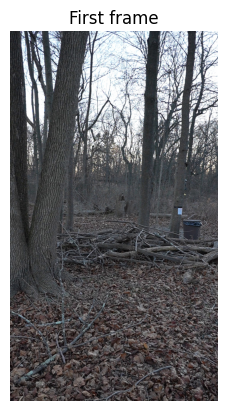

In [13]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────
QUERY_POSITIVE = ["tree"]
QUERY_NEGATIVE = ["ground"]

FEATURES  = CACHE_DIR / "semantics" / "features.zarr"
FEATURES.parent.mkdir(parents=True, exist_ok=True)

assert IMAGES.exists() and any(IMAGES.glob("*.jpg")), (
    f"No images in {IMAGES}. Run 01_preprocessing/keyframe_extraction first."
)

# Load first frame for feature extraction demo
frame_path = sorted(IMAGES.glob("*.jpg"))[0]
frame = np.array(Image.open(frame_path))
print(f"Loaded frame: {frame_path.name}  shape={frame.shape}")

plt.imshow(frame)
plt.axis("off")
plt.title("First frame")
plt.show()

## MaskCLIP

Patch-level CLIP features. Supports text query via `compute_similarity()`.

In [14]:
extractor_clip = MaskCLIPExtractor()
print("MaskCLIP loaded. Patch size:", extractor_clip.patch_size)

MaskCLIP loaded. Patch size: 14


In [15]:
# pil_frame = Image.fromarray(frame)
features_clip = extractor_clip.forward([frame])  # list of (C, pH, pW)
print("Feature shape:", features_clip[0].shape)  # e.g. (512, 24, 24)

Feature shape: torch.Size([768, 73, 41])


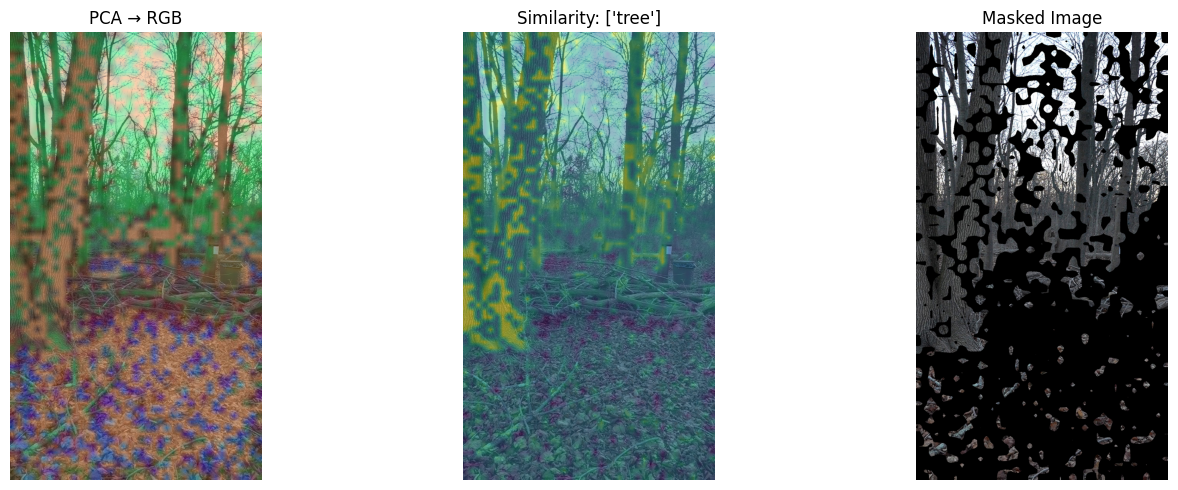

In [16]:
sim_map_clip = extractor_clip.score_queries(
    features_clip[0], positive=QUERY_POSITIVE, negative=QUERY_NEGATIVE,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
feature_viz_row(axes, frame, features_clip[0], sim_map_clip, query_label=str(QUERY_POSITIVE))
plt.tight_layout()
plt.show()

## Talk2DINO

DINOv3 backbone with CLIP text projection. Patch features + text-conditioned similarity.

`resize_mode="max_size"` (default): proportional longest-edge resize — preserves aspect ratio, no crop needed.

In [17]:
extractor_t2d = Talk2DinoExtractor(model_name="lorebianchi98/Talk2DINOv3-ViTB")
print("Talk2DINO loaded. Patch size:", extractor_t2d.patch_size)

/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/torch/nn/modules/module.py:2068: UserWarning: for cls_token: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/opt/conda/envs/nerfstudio/lib/python3.11/site-packages/torch/nn/modules/module.py:2068: UserWarning: for reg_token: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/opt/conda/envs/nerfstudio/lib/python3.11/site-packa

Talk2DINO loaded. Patch size: 16


In [ ]:
features_t2d = extractor_t2d.forward([frame])  # list of (D, H_p, W_p)
print("Feature shape:", features_t2d[0].shape)

In [ ]:
sim_t2d = extractor_t2d.score_queries(
    features_t2d[0], positive=QUERY_POSITIVE, negative=QUERY_NEGATIVE, temperature=0.05
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
feature_viz_row(axes, frame, features_t2d[0], sim_t2d, query_label=str(QUERY_POSITIVE))
plt.tight_layout()
plt.show()

## MaskCLIP vs Talk2DINO Comparison

Side-by-side feature comparison on the same image.
Both extractors use `resize_mode="max_size"` — proportional resize, same input frame for both.

In [ ]:
sim_clip = extractor_clip.score_queries(
    features_clip[0], positive=QUERY_POSITIVE, negative=QUERY_NEGATIVE
)
sim_t2d_cmp = extractor_t2d.score_queries(
    features_t2d[0], positive=QUERY_POSITIVE, negative=QUERY_NEGATIVE
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
feature_viz_row(axes[0], frame, features_clip[0], sim_clip, title_prefix="MaskCLIP: ", query_label=str(QUERY_POSITIVE))
feature_viz_row(axes[1], frame, features_t2d[0], sim_t2d_cmp, title_prefix="Talk2DINO: ", query_label=str(QUERY_POSITIVE))

plt.suptitle("MaskCLIP vs Talk2DINO feature comparison", fontsize=14)
plt.tight_layout()
plt.show()